In [25]:
import tensorflow as tf
import imghdr
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [26]:
import warnings
warnings.filterwarnings("ignore",category= DeprecationWarning)

In [27]:
data = tf.keras.utils.image_dataset_from_directory("Data")

Found 305 files belonging to 2 classes.


In [28]:
data_iterator = data.as_numpy_iterator()

In [29]:
batch = data_iterator.next()

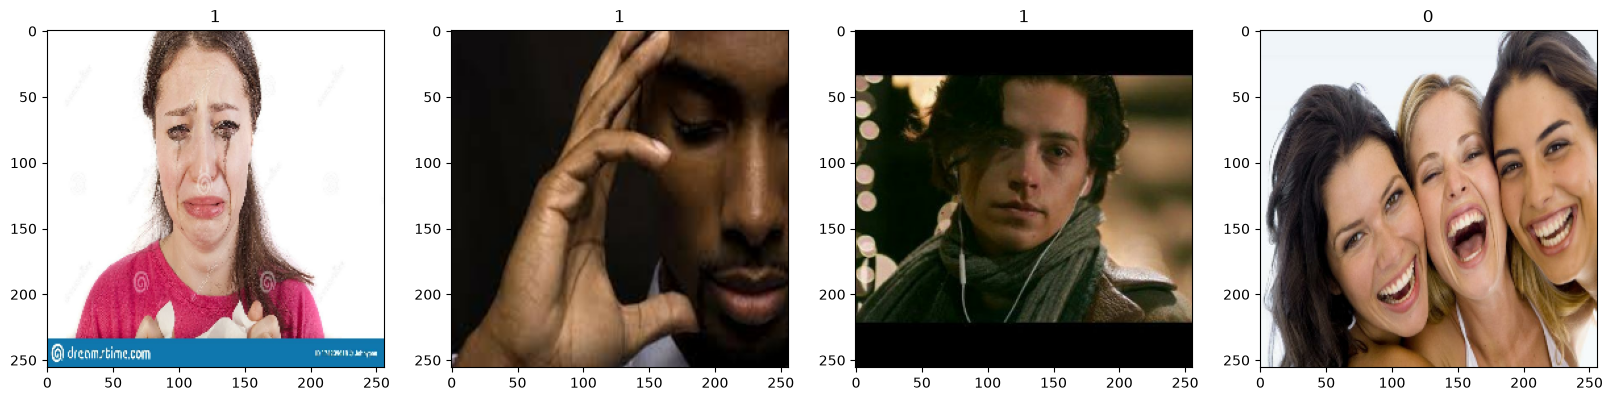

In [30]:
fig, ax = plt.subplots(ncols = 4, figsize= (20,20))

for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

## Scale the data

In [31]:
scaled_data = data.map(lambda x, y: (x/255, y))

In [32]:
scaled_iterator = scaled_data.as_numpy_iterator()

In [33]:
scaled_batche = scaled_iterator.next()

## Split the data into train validation and test

In [34]:
train_size = int(len(scaled_data) * 0.7)
val_size = int(len(scaled_data) * 0.2)
test_size = int(len(scaled_data) * 0.10)

In [35]:
train = scaled_data.take(train_size)
val = scaled_data.skip(train_size).take(val_size)
test = scaled_data.skip(train_size + val_size).take(test_size)

## Deep learing model 

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense , Flatten, Dropout

## input layer


In [37]:
model = Sequential()

model.add(Conv2D(16, (3,3), 1, activation="relu",input_shape = (256, 256, 3)))
model.add(MaxPool2D())



/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.add(Conv2D(32, (3,3),1,activation="relu"))
model.add(MaxPool2D())

In [39]:
model.add(Conv2D(16, (3,3), 1, activation="relu"))
model.add(MaxPool2D())


In [40]:
model.add(Flatten())

In [41]:
model.add(Dense(265, activation="relu"))

In [42]:
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.compile(optimizer="adam",loss = tf.losses.BinaryCrossentropy(), metrics = ["accuracy"])

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 265)            │     3,816,265 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           266 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,826,243 (14.60 MB)

 Trainable params: 3,826,243 (14.60 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir ="logs")

In [46]:
trained_model = model.fit(train,epochs= 20, validation_data= val, callbacks= [tensorboard_callback])

Epoch 1/20


/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.4777 - loss: 1.1443 - val_accuracy: 0.5000 - val_loss: 0.6444
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.5268 - loss: 0.7090 - val_accuracy: 0.6250 - val_loss: 0.6623
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.6607 - loss: 0.6167 - val_accuracy: 0.6094 - val_loss: 0.5476
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.7098 - loss: 0.5534 - val_accuracy: 0.9219 - val_loss: 0.3729
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.7768 - loss: 0.4622 - val_accuracy: 0.7812 - val_loss: 0.4706
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.8482 - loss: 0.4087 - val_accuracy: 0.9062 - val_loss: 0.2836
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.8839 - loss: 0.3027 - val_accuracy: 0.8438 - val_loss: 0.3618
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.8750 - loss: 0.3407 - val_accuracy: 0.8906 - val_loss: 0.3425
Epo

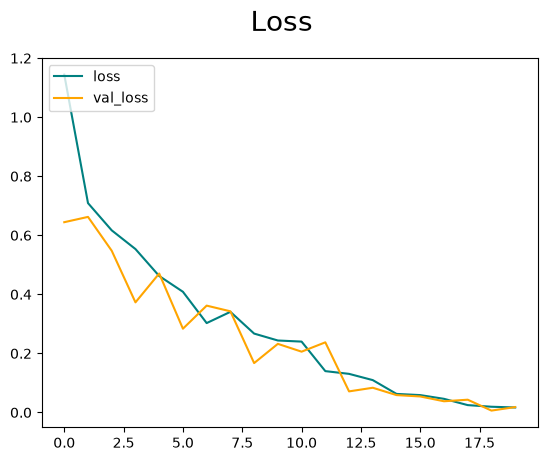

In [47]:
fig = plt.figure()
plt.plot(trained_model.history['loss'], color='teal', label='loss')
plt.plot(trained_model.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()


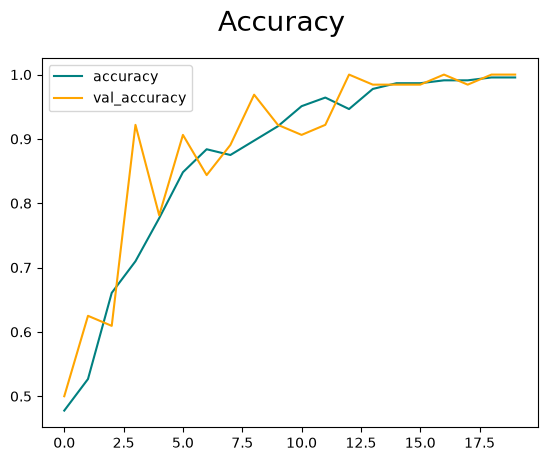

In [48]:
fig = plt.figure()
plt.plot(trained_model.history['accuracy'], color='teal', label='accuracy')
plt.plot(trained_model.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()


## Evaluate the model

In [50]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

precision = Precision()
recall = Recall()
bin_acc = BinaryAccuracy()

In [51]:
len(test)

1

In [54]:
for batch in test.as_numpy_iterator():
    X,y = batch
    ypred = model.predict(X)
    precision.update_state(y,ypred)
    recall.update_state(y,ypred)
    bin_acc.update_state(y,ypred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [57]:
print(f"Precision{precision.result()}\n Reacll: {recall.result()}\n BinaryAccuracy{bin_acc.result()}")

Precision1.0
 Reacll: 1.0
 BinaryAccuracy1.0
